# 3W Dataset: Exploratory Data Analysis

The 3W dataset is a realistic and public dataset with rare undesirable real events in oil wells. It contains instances from three sources: real data, simulated (OLGA multiphase flow simulator), and hand-drawn curves by domain experts.

## Dataset overview (from paper's information)

- **Domain**: Offshore naturally flowing oil & gas wells
- **Sensors**: 8 process variables (pressure, temperature, flow)
- **Classes**: 1 normal + 8 undesirable event types
- **Sources**: Real (1025) + Simulated/OLGA (939) + Hand-drawn (20) = 1,984 total
- **Sampling**: 1 Hz (fixed rate)
- **Labeling**: Instance-level + observation-level (normal / faulty transient / faulty steady state)
- **Data quality**: Real: NaN, frozen vars, outliers. Simulated/hand-drawn: clean.
- **Time span**: mid-2012 to mid-2018 (real instances)

## 1. Setup and data loading

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

EXTRACTED_DATA_DIR = os.path.join(
    PROJECT_ROOT, 'data',
    'Data for A Realistic and Public Dataset with Rare Undesirable Real Events in Oil Wells',
    'data'
)

CLASS_NAMES = {
    0: 'Normal',
    1: 'Abrupt Increase of BSW',
    2: 'Spurious Closure of DHSV',
    3: 'Severe Slugging',
    4: 'Flow Instability',
    5: 'Rapid Productivity Loss',
    6: 'Quick Restriction in PCK',
    7: 'Scaling in PCK',
    8: 'Hydrate in Production Line',
}
VARIABLE_NAMES = ['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP',
                  'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL']
SOURCES = ['real', 'simulated', 'handdrawn']


In [3]:
extracted_dirs = [os.path.join(EXTRACTED_DATA_DIR, str(i)) for i in range(9)]
extracted_exists = all(os.path.isdir(d) for d in extracted_dirs)

if not extracted_exists:
    import py7zr
    archive_dir = os.path.dirname(EXTRACTED_DATA_DIR)
    parts = [os.path.join(archive_dir, f'data.7z.{str(i).zfill(3)}') for i in range(1, 5)]
    combined_path = os.path.join(archive_dir, 'data_combined.7z')
    
    if not os.path.exists(combined_path):
        # concatenate 7z parts into a single file
        with open(combined_path, 'wb') as out:
            for part in parts:
                with open(part, 'rb') as f:
                    out.write(f.read())
    
    with py7zr.SevenZipFile(combined_path, mode='r') as sz:
        sz.extractall(path=archive_dir)
    
    extracted_exists = all(os.path.isdir(d) for d in extracted_dirs)
    print('Extraction complete' if extracted_exists else 'Extraction failed')

if extracted_exists:
    print('Dataset extracted')
    for d in sorted(extracted_dirs):
        csv_count = len(glob.glob(os.path.join(d, '*.csv')))
        class_name = CLASS_NAMES.get(int(os.path.basename(d)), 'Unknown')
        print(f'\tClass {os.path.basename(d)} ({class_name}): {csv_count} CSV files')
else:
    print('Dataset not present')
    raise SystemExit(0)

Dataset extracted
	Class 0 (Normal): 597 CSV files
	Class 1 (Abrupt Increase of BSW): 129 CSV files
	Class 2 (Spurious Closure of DHSV): 38 CSV files
	Class 3 (Severe Slugging): 106 CSV files
	Class 4 (Flow Instability): 344 CSV files
	Class 5 (Rapid Productivity Loss): 451 CSV files
	Class 6 (Quick Restriction in PCK): 221 CSV files
	Class 7 (Scaling in PCK): 14 CSV files
	Class 8 (Hydrate in Production Line): 84 CSV files


In [4]:
def detect_source(filename):
    """Determine instance source from filename
    Args:
        filename (str): CSV filename
    Returns:
        str: 'handdrawn', 'simulated', 'real', or 'unknown'
    """
    name = os.path.splitext(filename)[0]
    if name.startswith('DRAWN'):
        return 'handdrawn'
    elif name.startswith('SIMULATED'):
        return 'simulated'
    elif name.startswith('WELL'):
        return 'real'
    return 'unknown'

def load_all_instances(data_dir, class_names):
    """Load all CSV files from the extracted dataset.
    Args:
        data_dir (str): Path to the extracted dataset directory
        class_names (dict): Mapping of class codes to class names
    
    Returns: {class_code: {source: [{id, path, data, n_vars, n_obs}, ...], ...}, ...}
    """
    all_instances = {}
    
    for class_code in class_names:
        class_dir = os.path.join(data_dir, str(class_code))
        if not os.path.isdir(class_dir):
            continue
        
        csv_files = sorted(glob.glob(os.path.join(class_dir, '*.csv')))
        if not csv_files:
            continue
        
        class_instances = {}
        for fpath in csv_files:
            fname = os.path.basename(fpath)
            source = detect_source(fname)
            
            try:
                df = pd.read_csv(fpath)
                if 'timestamp' in df.columns:
                    df['timestamp'] = pd.to_datetime(df['timestamp'])
                
                instance_id = os.path.splitext(fname)[0]
                
                if source not in class_instances:
                    class_instances[source] = []
                class_instances[source].append({
                    'id': instance_id,
                    'path': fpath,
                    'data': df,
                    'n_vars': len([c for c in df.columns if c != 'timestamp' and c != 'class']),
                    'n_obs': df.shape[0],
                })
            except Exception as e:
                print(f'\t[ERROR] {fname}: {e}')
        
        if class_instances:
            all_instances[class_code] = class_instances
    
    return all_instances


data = load_all_instances(EXTRACTED_DATA_DIR, CLASS_NAMES)

total_instances = sum(
    sum(len(lst) for lst in src_dict.values())
    for src_dict in data.values()
)
print(f'\nLoaded {total_instances} instances')


Loaded 1984 instances


## 2. Dataset composition

We will count the instances per event type and per source, and visualize the class imbalance with a bar chart, a stacked bar chart, and a pie chart.

In [5]:
composition = []
for class_code in sorted(data.keys()):
    row = {'Class': class_code, 'Event': CLASS_NAMES[class_code]}
    for src in ['real', 'simulated', 'handdrawn']:
        row[src.capitalize()] = len(data[class_code].get(src, []))
    row['Total'] = sum(row[s.capitalize()] for s in ['real', 'simulated', 'handdrawn'])
    composition.append(row)

comp_df = pd.DataFrame(composition)
comp_df.set_index('Class', inplace=True)
comp_df

,Event,Real,Simulated,Handdrawn,Total
Class,,,,,
0,Normal,597,0,0,597
1,Abrupt Increase of BSW,5,114,10,129
2,Spurious Closure of DHSV,22,16,0,38
3,Severe Slugging,32,74,0,106
4,Flow Instability,344,0,0,344
5,Rapid Productivity Loss,12,439,0,451
6,Quick Restriction in PCK,6,215,0,221
7,Scaling in PCK,4,0,10,14
8,Hydrate in Production Line,3,81,0,84


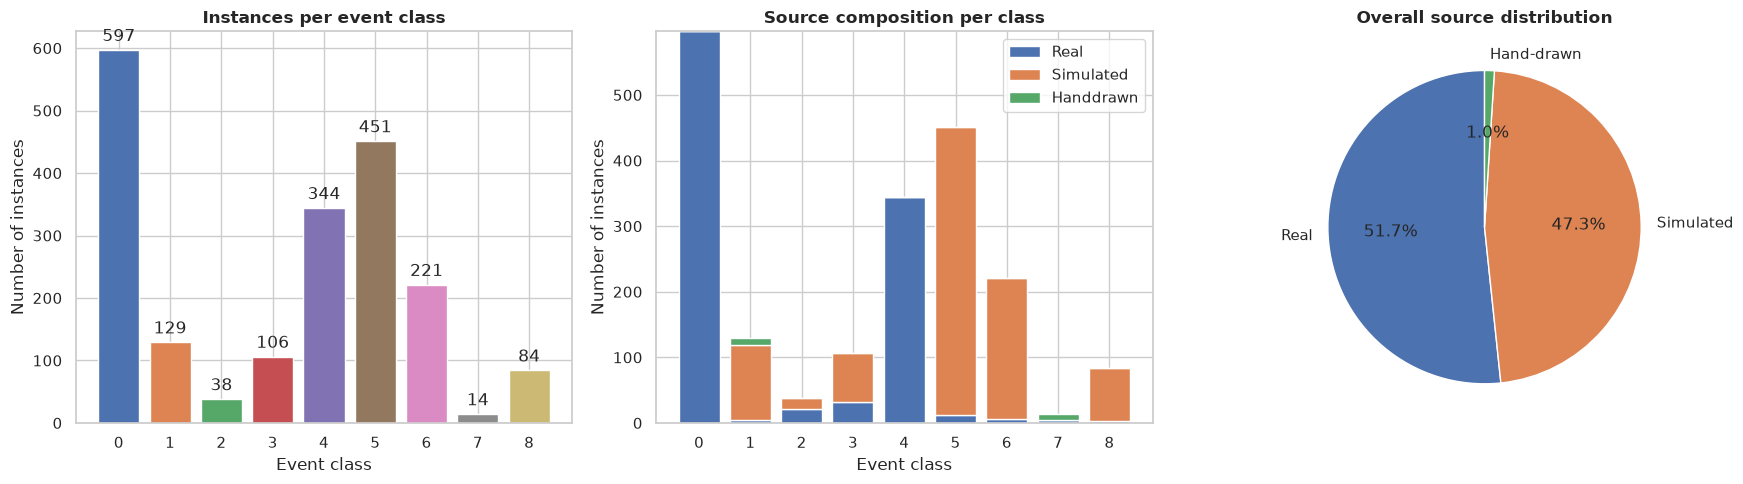

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Instances per class
ax = axes[0]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3',
          '#937860', '#DA8BC3', '#8C8C8C', '#CCB974']
bars = ax.bar(comp_df.index, comp_df['Total'], color=colors, edgecolor='white')
ax.set_xlabel('Event class')
ax.set_ylabel('Number of instances')
ax.set_title('Instances per event class', fontweight='bold')
ax.set_xticks(range(9))
ax.set_xticklabels([f'{i}' for i in range(9)], rotation=0)
for bar, val in zip(bars, comp_df['Total']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(val), ha='center', va='bottom')

# Source distribution
ax = axes[1]
src_colors = ['#4C72B0', '#DD8452', '#55A868']
bottom = np.zeros(9)
for idx, src in enumerate(['real', 'simulated', 'handdrawn']):
    vals = comp_df[f'{src.capitalize()}'].values
    ax.bar(comp_df.index, vals, bottom=bottom, label=src.capitalize(),
           color=src_colors[idx], edgecolor='white')
    bottom += vals
ax.set_xlabel('Event class')
ax.set_ylabel('Number of instances')
ax.set_title('Source composition per class', fontweight='bold')
ax.set_xticks(range(9))
ax.legend()

# Overall source proportions
ax = axes[2]
source_totals = [
    sum(comp_df[f'{s.capitalize()}']) for s in ['real', 'simulated', 'handdrawn']
]
ax.pie(source_totals, labels=['Real', 'Simulated', 'Hand-drawn'],
       colors=src_colors, autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white'})
ax.set_title('Overall source distribution', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Signal exploration

We will list the 8 process variables, inspect which variables each instance actually contains, and measure their prevalence in the normal class.

In [7]:
print('\nVariables found:')
for i, v in enumerate(VARIABLE_NAMES):
    print(f'  {i+1}. {v}')

seen_columns = set()
for cls in sorted(data.keys()):
    for src in data[cls]:
        for inst in data[cls][src][:1]:
            cols = set(inst['data'].columns) - {'timestamp', 'class'}
            seen_columns.update(cols)
            missing = set(VARIABLE_NAMES) - cols
            n_vars = inst['n_vars']
            print(f'\tClass {cls} | {src:10s} | {inst["id"][:25]:25s} | {n_vars} vars | missing: {", ".join(missing) if missing else "none"}')

print(f'\nUnique variables: {sorted(seen_columns)}')


Variables found:
  1. P-PDG
  2. P-TPT
  3. T-TPT
  4. P-MON-CKP
  5. T-JUS-CKP
  6. P-JUS-CKGL
  7. T-JUS-CKGL
  8. QGL
	Class 0 | real       | WELL-00001_20170201020207 | 8 vars | missing: none
	Class 1 | handdrawn  | DRAWN_00001               | 8 vars | missing: none
	Class 1 | simulated  | SIMULATED_00001           | 8 vars | missing: none
	Class 1 | real       | WELL-00001_20140124213136 | 8 vars | missing: none
	Class 2 | simulated  | SIMULATED_00001           | 8 vars | missing: none
	Class 2 | real       | WELL-00002_20131104014101 | 8 vars | missing: none
	Class 3 | simulated  | SIMULATED_00001           | 8 vars | missing: none
	Class 3 | real       | WELL-00001_20170320130025 | 8 vars | missing: none
	Class 4 | real       | WELL-00001_20170316120203 | 8 vars | missing: none
	Class 5 | simulated  | SIMULATED_00001           | 8 vars | missing: none
	Class 5 | real       | WELL-00015_20170620160349 | 8 vars | missing: none
	Class 6 | simulated  | SIMULATED_00001           | 8

In [8]:
if 0 in data and 'real' in data[0]:
    normal_real = data[0]['real']
    print(f'Found {len(normal_real)} normal real instances')
    
    var_counts = {v: 0 for v in VARIABLE_NAMES}
    total_counted = 0
    for inst in normal_real:
        total_counted += 1
        for v in VARIABLE_NAMES:
            if v in inst['data'].columns and not inst['data'][v].isna().all():
                var_counts[v] += 1
    
    print(f'\nVariable prevalence in Class 0 real instances ({total_counted} instances):')
    var_prev = pd.DataFrame([{'Variable': v, 'Present_in_n_instances': c,
                              'Pct': f'{100*c/total_counted:.1f}%'}
                             for v, c in var_counts.items()])
    display(var_prev)
    
    first = normal_real[0]['data']
    print(f'\nDescriptive stats (first instance: {normal_real[0]["id"]}):')
    cols_to_show = [c for c in VARIABLE_NAMES if c in first.columns]
    display(first[cols_to_show].describe())

Found 597 normal real instances



Variable prevalence in Class 0 real instances (597 instances):


,Variable,Present_in_n_instances,Pct
0,P-PDG,597,100.0%
1,P-TPT,597,100.0%
2,T-TPT,597,100.0%
3,P-MON-CKP,540,90.5%
4,T-JUS-CKP,514,86.1%
5,P-JUS-CKGL,419,70.2%
6,T-JUS-CKGL,0,0.0%
7,QGL,421,70.5%



Descriptive stats (first instance: WELL-00001_20170201020207):


,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,T-JUS-CKGL,QGL
count,17874.0,1.787400e+04,17874.000000,1.787400e+04,17874.000000,1.787400e+04,0.0,17874.0
mean,0.0,1.005535e+07,119.032772,1.579691e+06,84.236402,1.565949e+06,NaN,0.0
std,0.0,2.129230e+04,0.036517,1.783858e+05,0.413930,1.040054e+03,NaN,0.0
min,0.0,9.994737e+06,118.942100,9.960668e+05,82.689530,1.564147e+06,NaN,0.0
25%,0.0,1.004210e+07,118.997600,1.473036e+06,83.962502,1.565048e+06,NaN,0.0
50%,0.0,1.005459e+07,119.038100,1.589945e+06,84.277200,1.565949e+06,NaN,0.0
75%,0.0,1.007454e+07,119.059300,1.690882e+06,84.536448,1.566849e+06,NaN,0.0
max,0.0,1.009448e+07,119.098300,2.240969e+06,85.378270,1.567750e+06,NaN,0.0


## 4. Temporal structure

At 1 Hz sampling, each observation corresponds to one second, and the instance duration varies by event type. We will compare the durations across classes and sources, and look at an example time series per class.

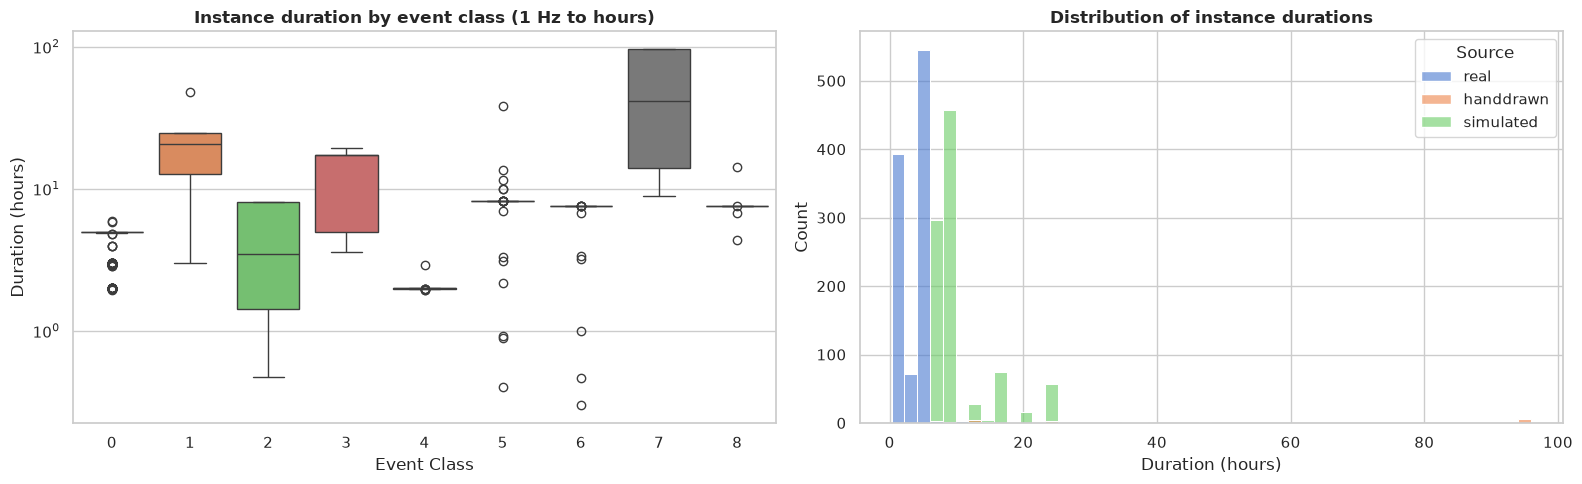


Duration statistics per class (hours):


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,597.0,4.63,0.83,1.95,4.92,4.97,4.98,5.96
1,129.0,19.36,6.65,2.99,12.67,20.67,24.67,48.00
2,38.0,4.53,3.19,0.47,1.43,3.50,8.00,8.00
3,106.0,12.67,5.65,3.61,4.99,17.22,17.22,19.44
4,344.0,1.99,0.05,1.94,1.98,1.99,1.99,2.93
5,451.0,8.15,1.62,0.40,8.14,8.14,8.14,37.93
6,221.0,7.36,0.89,0.30,7.50,7.50,7.50,7.50
7,14.0,53.39,39.60,8.94,14.00,41.54,96.00,96.00
8,84.0,7.53,0.82,4.36,7.50,7.50,7.50,14.22


In [9]:
length_data = []
for cls in sorted(data.keys()):
    for src in data[cls]:
        for inst in data[cls][src]:
            length_data.append({
                'Class': cls,
                'Event': CLASS_NAMES[cls][:20],
                'Source': src,
                'Observations': inst['n_obs'],
                'Duration_hours': inst['n_obs'] / 3600,
            })

length_df = pd.DataFrame(length_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
sns.boxplot(data=length_df, x='Class', y='Duration_hours', ax=ax, palette='muted')
ax.set_title('Instance duration by event class (1 Hz to hours)', fontweight='bold')
ax.set_ylabel('Duration (hours)')
ax.set_yscale('log')
ax.set_xlabel('Event Class')

ax = axes[1]
sns.histplot(data=length_df, x='Duration_hours', hue='Source', bins=50, ax=ax, alpha=0.6)
ax.set_title('Distribution of instance durations', fontweight='bold')
ax.set_xlabel('Duration (hours)')

plt.tight_layout()
plt.show()

print('\nDuration statistics per class (hours):')
display(length_df.groupby('Class')['Duration_hours'].describe().round(2))

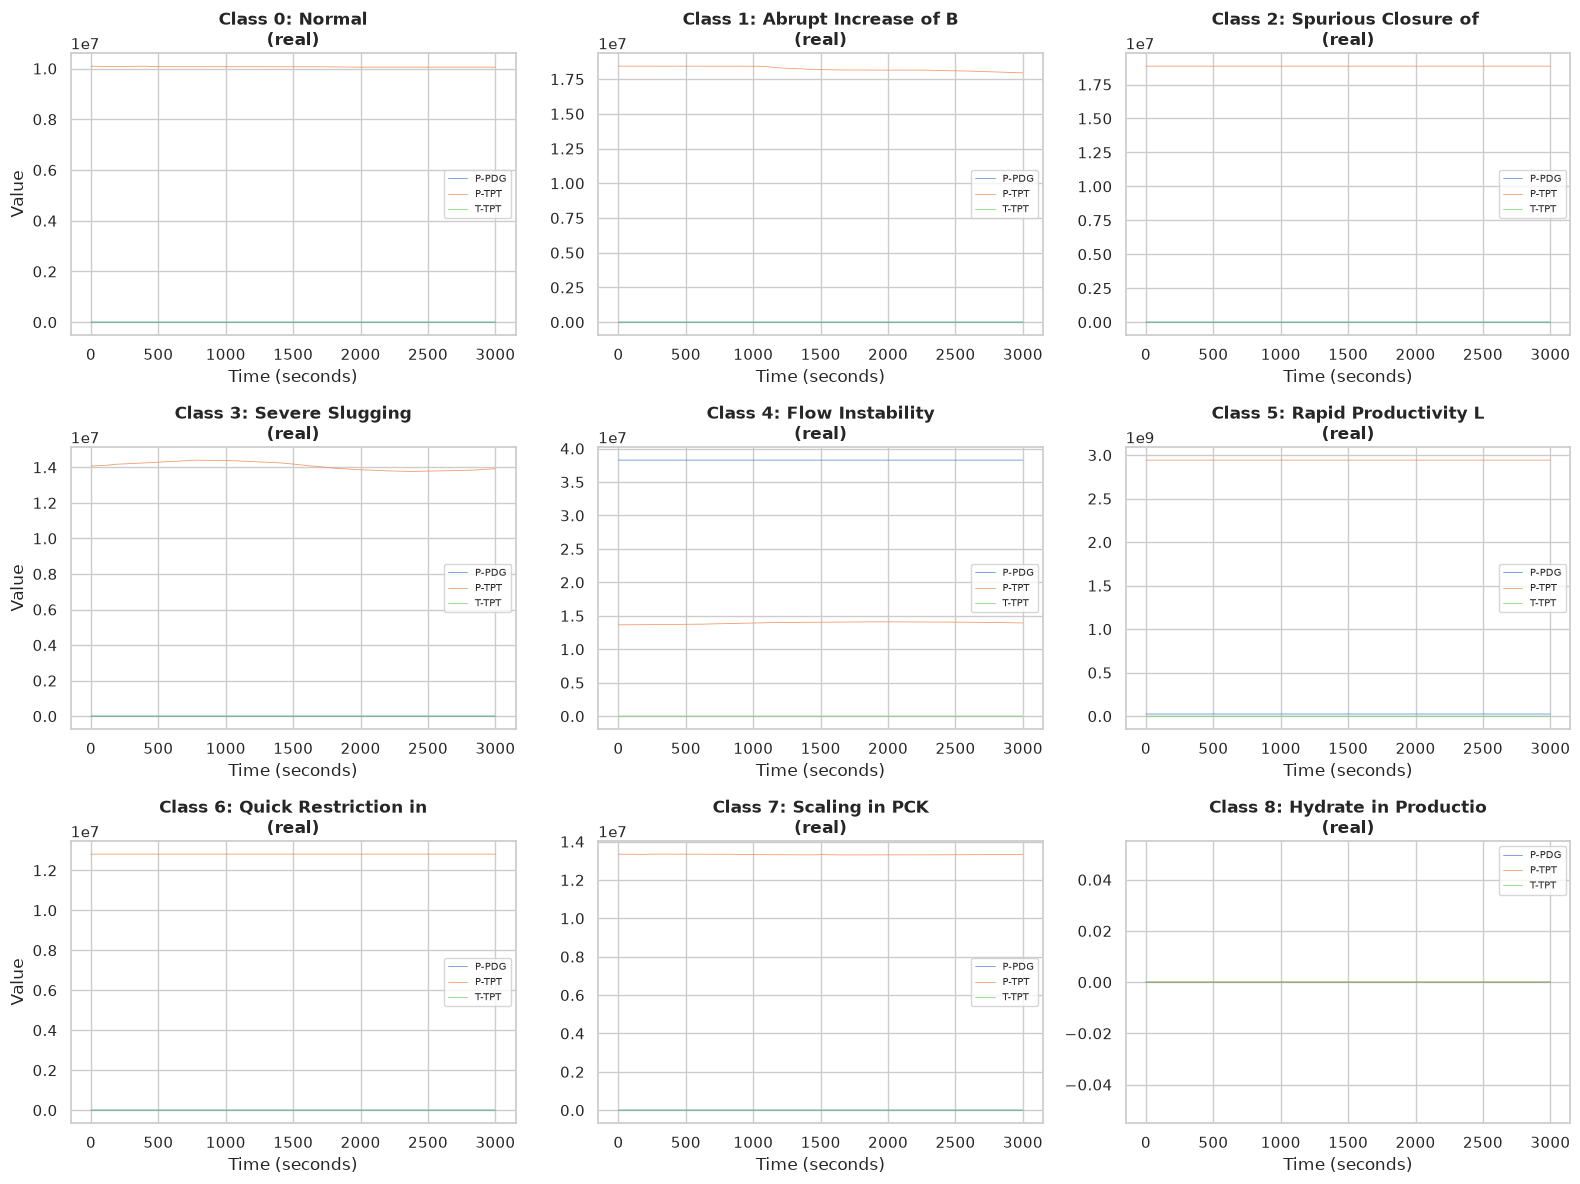

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for cls in sorted(data.keys()):
    ax = axes[cls // 3][cls % 3]
    
    inst = None
    inst_src = ''
    for src in ['real', 'simulated', 'handdrawn']:
        if src in data[cls] and len(data[cls][src]) > 0:
            inst = data[cls][src][0]
            inst_src = src
            break
    
    if inst is not None:
        df = inst['data']
        cols_to_plot = [c for c in VARIABLE_NAMES[:3] if c in df.columns]
        for var in cols_to_plot:
            vals = df[var].values[:3000]
            ax.plot(vals, linewidth=0.6, alpha=0.8, label=var[:10])
        ax.set_title(f'Class {cls}: {CLASS_NAMES[cls][:20]}\n({inst_src})', fontweight='bold')
        ax.legend(fontsize=7)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Class {cls}', fontweight='bold')
    
    ax.set_xlabel('Time (seconds)')
    if cls % 3 == 0:
        ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

## 5. Label granularity

The dataset has two labeling levels:
1. **Instance-level**: Each CSV is in a directory named after its event class (0-8)
2. **Observation-level**: Each row has additional columns marking normal (green), faulty transient (yellow), or faulty steady state (red) periods

### Encoding scheme
- `0`: normal period (no anomaly)
- `N`: faulty transient for event N (event developing, dynamics ongoing)
- `10N`: faulty steady state for event N (event fully established)
- `NaN`: unlabeled observation

In [11]:
CLASS = 1

print(f'Columns: {VARIABLE_NAMES}')

if CLASS in data and 'real' in data[CLASS]:
    sample = data[CLASS]['real'][0]
    df = sample['data']
    print(f'Instance: {sample["id"]} | Shape: {df.shape}')
    print(f'Columns: {list(df.columns)}')
    display(df.head(3))
    
    class_vals = df['class'].value_counts(dropna=False).sort_index()
    print(f'Class column unique values:')
    print(class_vals.to_string())
    print(f'\nInterpretation:')
    print(f'  0      = normal period')
    print(f'  {CLASS}      = faulty transient for event type {CLASS} ({CLASS_NAMES[CLASS]})')
    print(f'  10{CLASS}    = faulty steady state for event type {CLASS}')
    print(f'  NaN    = unlabeled observation')

Columns: ['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL']
Instance: WELL-00001_20140124213136 | Shape: (12505, 10)
Columns: ['timestamp', 'P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL', 'class']


,timestamp,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,T-JUS-CKGL,QGL,class
0,2014-01-24 21:31:36,0.0,18433410.0,116.9109,9366608.0,75.34820,-300917.8,NaN,0.0,0.0
1,2014-01-24 21:31:37,0.0,18433410.0,116.9109,9366602.0,75.34825,-300917.8,NaN,0.0,0.0
2,2014-01-24 21:31:38,0.0,18433410.0,116.9109,9366598.0,75.34831,-300917.8,NaN,0.0,0.0


Class column unique values:
class
0.0       959
1.0      1781
101.0    9700
NaN        65

Interpretation:
  0      = normal period
  1      = faulty transient for event type 1 (Abrupt Increase of BSW)
  101    = faulty steady state for event type 1
  NaN    = unlabeled observation


### Visualize the annotated regions
- **Green** = normal period
- **Yellow** = faulty transient (event developing)
- **Red** = faulty steady state (event fully established)
- **White** = unlabeled

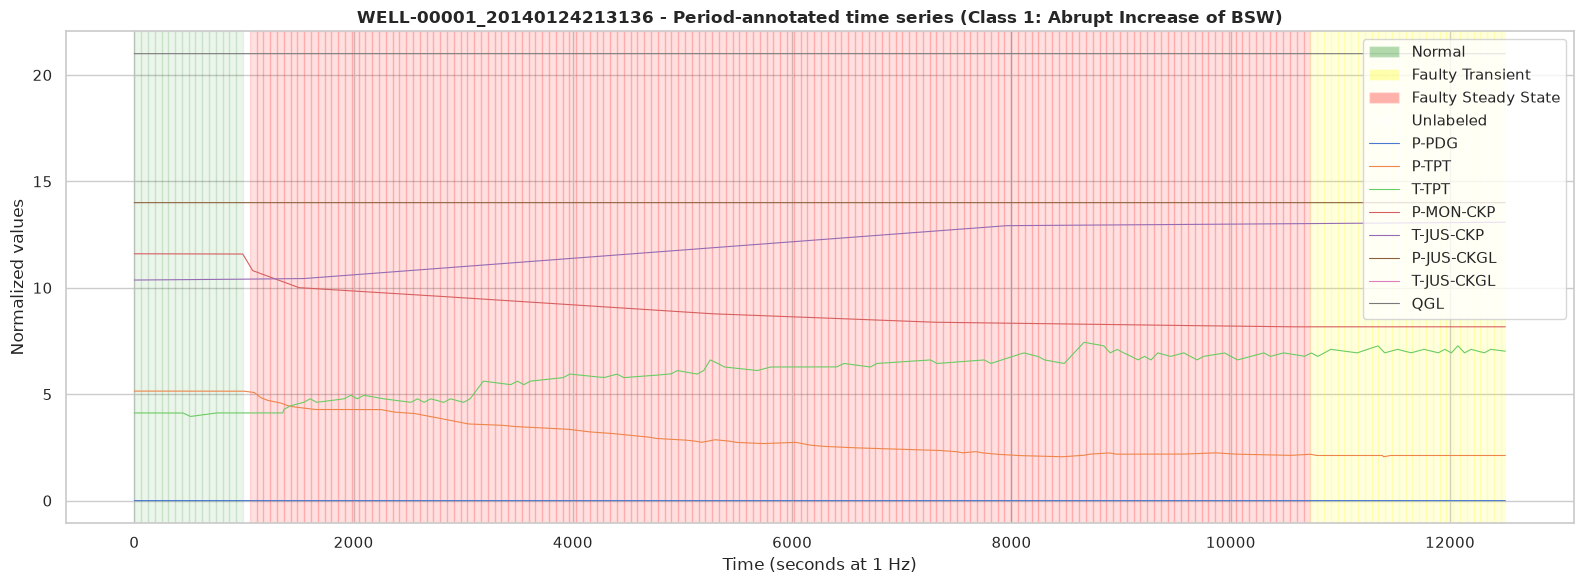

In [12]:
if CLASS in data and 'real' in data[CLASS]:
    sample = data[CLASS]['real'][0]
    df = sample['data']
    
    fig, ax = plt.subplots(figsize=(16, 6))
    
    t = np.arange(len(df))
    for i, var in enumerate(VARIABLE_NAMES):
        if var in df.columns:
            vals = df[var].values
            if np.nanstd(vals) > 0:
                vals = (vals - np.nanmean(vals)) / np.nanstd(vals)
            ax.plot(t, vals + i*3, linewidth=0.8, label=var)
    
    labels = df['class'].values
    step = max(1, len(labels) // 200)
    
    for idx in range(0, len(labels), step):
        lbl = labels[idx]
        if lbl == 0:
            color, alpha = 'green', 0.08
        elif isinstance(lbl, float) and np.isnan(lbl):
            color, alpha = 'white', 0.08
        elif lbl in range(1, 9):
            color, alpha = 'yellow', 0.12
        elif lbl in range(101, 109):
            color, alpha = 'red', 0.12
        else:
            continue
        ax.axvspan(idx, min(idx + step, len(labels)), alpha=alpha, color=color)
    
    legend_elements = [
        Patch(facecolor='green', alpha=0.3, label='Normal'),
        Patch(facecolor='yellow', alpha=0.3, label='Faulty Transient'),
        Patch(facecolor='red', alpha=0.3, label='Faulty Steady State'),
        Patch(facecolor='white', alpha=0.3, label='Unlabeled'),
    ]
    handles = legend_elements + [
        plt.Line2D([0], [0], color=f'C{i}', linewidth=0.8, label=var)
        for i, var in enumerate(VARIABLE_NAMES) if var in df.columns
    ]
    ax.legend(handles=handles, loc='upper right')
    
    ax.set_title(f'{sample["id"]} - Period-annotated time series (Class {CLASS}: {CLASS_NAMES[CLASS]})',
                 fontweight='bold')
    ax.set_xlabel('Time (seconds at 1 Hz)')
    ax.set_ylabel('Normalized values')
    
    plt.tight_layout()
    plt.show()

## 6. Data quality assessment

We will assess the data quality across the three sources, looking at:
- **Missing variables**: variables entirely absent from an instance
- **Frozen variables**: sensors stuck at a constant value, mostly in real instances
- **Unlabeled observations**: missing values in the class column

In [13]:
print('Missing variables\n')

all_missing_info = []
for cls in sorted(data.keys()):
    for src in data[cls]:
        for inst in data[cls][src]:
            df = inst['data']
            var_cols = [c for c in VARIABLE_NAMES if c in df.columns]
            n_total = len(var_cols)
            n_missing = sum(1 for c in var_cols if df[c].isna().all())
            all_missing_info.append({
                'Class': cls,
                'Source': src,
                'Instance': inst['id'],
                'Total_vars': n_total,
                'Missing_vars': n_missing,
                'Missing_pct': 100 * n_missing / n_total if n_total > 0 else 0,
            })

missing_df = pd.DataFrame(all_missing_info)
total_vars_all = missing_df['Total_vars'].sum()
total_missing_all = missing_df['Missing_vars'].sum()
print(f'Total instances analyzed: {len(missing_df)}')
print(f'Total variables (all instances): {total_vars_all}')
print(f'Total missing variables: {total_missing_all}')
print(f'Overall missing rate: {100 * total_missing_all / total_vars_all:.2f}%' if total_vars_all > 0 else 'N/A')

print(f'\nMissing rate by source:')
print(missing_df.groupby('Source')['Missing_pct'].describe().round(2))

Missing variables



Total instances analyzed: 1984
Total variables (all instances): 15872
Total missing variables: 4947
Overall missing rate: 31.17%

Missing rate by source:
            count   mean    std   min   25%   50%   75%   max
Source                                                       
handdrawn    20.0  37.50   0.00  37.5  37.5  37.5  37.5  37.5
real       1025.0  22.62  15.38  12.5  12.5  12.5  37.5  62.5
simulated   939.0  40.36   5.25  37.5  37.5  37.5  37.5  50.0


In [14]:
print('Frozen variables\n')

frozen_info = []
for cls in sorted(data.keys()):
    for src in data[cls]:
        for inst in data[cls][src]:
            df = inst['data']
            var_cols = [c for c in VARIABLE_NAMES if c in df.columns]
            n_total = len(var_cols)
            n_frozen = sum(1 for c in var_cols
                          if df[c].nunique(dropna=False) == 1 and not df[c].isna().all())
            frozen_info.append({
                'Class': cls,
                'Source': src,
                'Instance': inst['id'],
                'Total_vars': n_total,
                'Frozen_vars': n_frozen,
                'Frozen_pct': 100 * n_frozen / n_total if n_total > 0 else 0,
            })

frozen_df = pd.DataFrame(frozen_info)
total_vars_all = frozen_df['Total_vars'].sum()
total_frozen_all = frozen_df['Frozen_vars'].sum()
print(f'Total variables (all instances): {total_vars_all}')
print(f'Total frozen variables: {total_frozen_all}')
print(f'Overall frozen rate: {100 * total_frozen_all / total_vars_all:.2f}%' if total_vars_all > 0 else 'N/A')

print(f'\nFrozen rate by source:')
print(frozen_df.groupby('Source')['Frozen_pct'].describe().round(2))

Frozen variables



Total variables (all instances): 15872
Total frozen variables: 1535
Overall frozen rate: 9.67%

Frozen rate by source:
            count   mean    std  min   25%   50%   75%   max
Source                                                      
handdrawn    20.0   0.00   0.00  0.0   0.0   0.0   0.0   0.0
real       1025.0  18.72  13.19  0.0  12.5  25.0  25.0  50.0
simulated   939.0   0.00   0.00  0.0   0.0   0.0   0.0   0.0


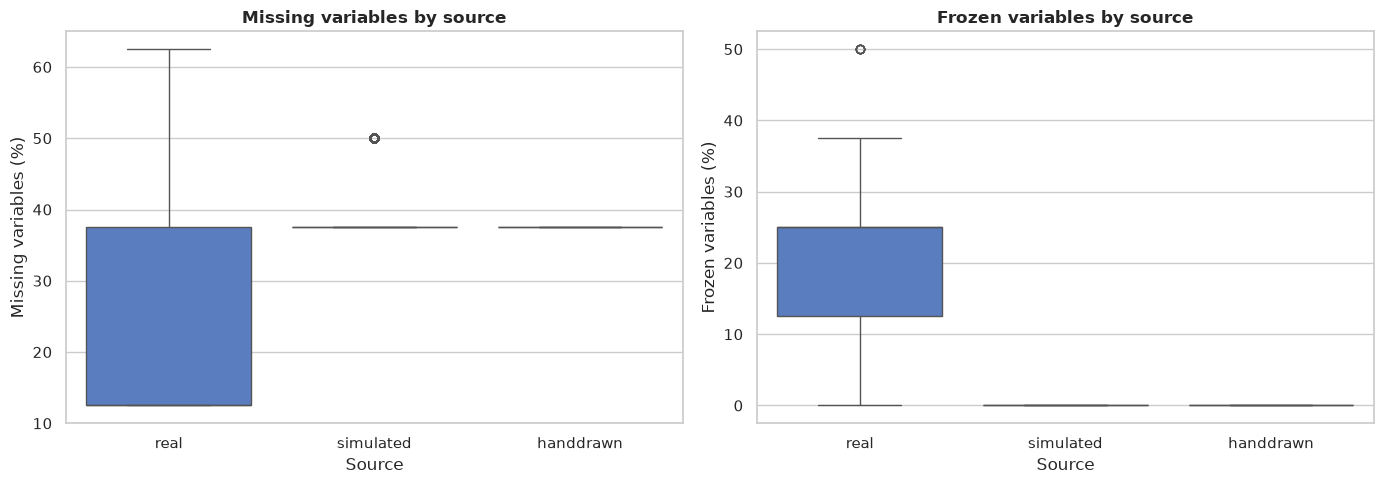

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing rate by source
ax = axes[0]
sns.boxplot(data=missing_df, x='Source', y='Missing_pct', ax=ax, order=['real', 'simulated', 'handdrawn'])
ax.set_title('Missing variables by source', fontweight='bold')
ax.set_ylabel('Missing variables (%)')

# Frozen rate by source
ax = axes[1]
sns.boxplot(data=frozen_df, x='Source', y='Frozen_pct', ax=ax, order=['real', 'simulated', 'handdrawn'])
ax.set_title('Frozen variables by source', fontweight='bold')
ax.set_ylabel('Frozen variables (%)')

plt.tight_layout()
plt.show()

## 7. Correlation heatmap

We will compute the Pearson correlation between the 8 process variables separately for each source, and compare the three correlation structures side by side.

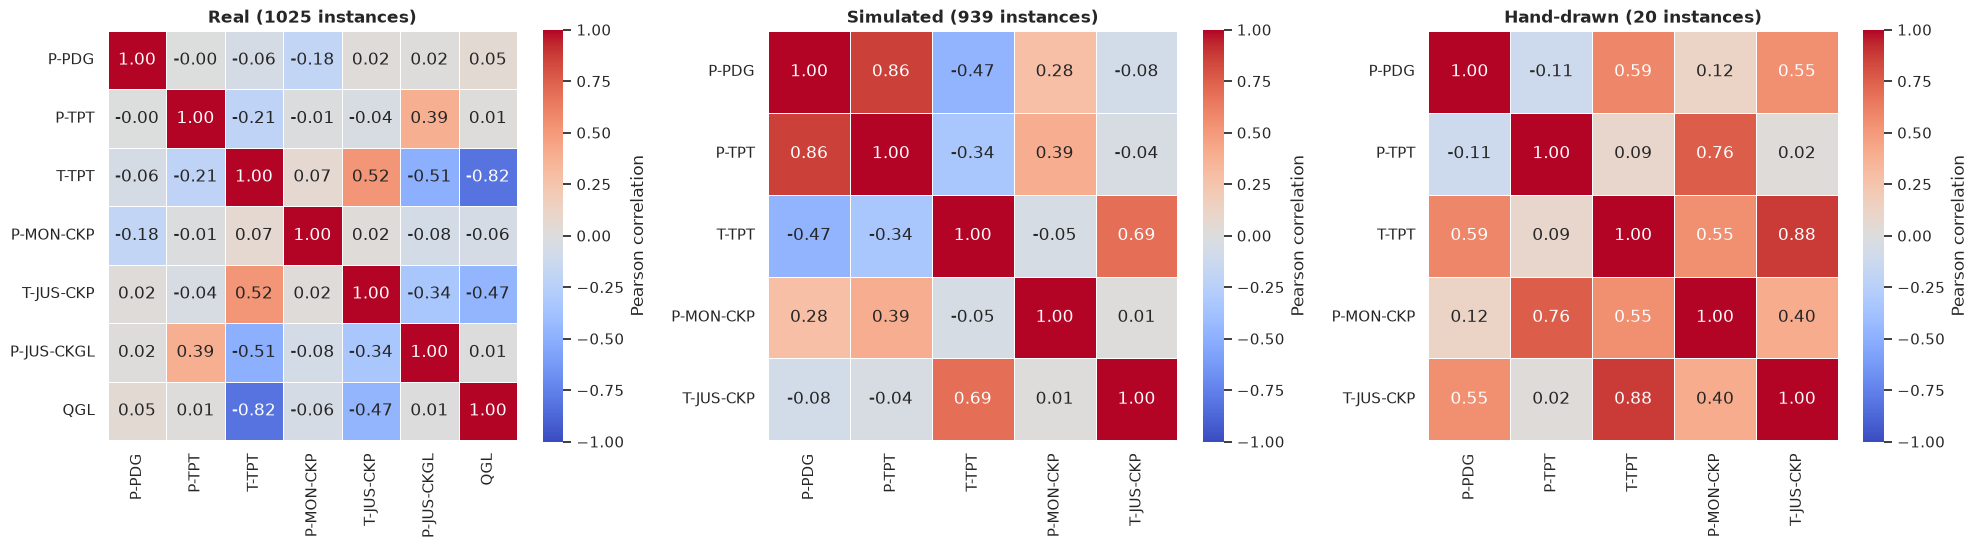

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
source_labels = {'real': 'Real', 'simulated': 'Simulated', 'handdrawn': 'Hand-drawn'}

for ax, (src_key, src_label) in zip(axes, source_labels.items()):
    frames = []
    for cls in data:
        if src_key in data[cls]:
            for inst in data[cls][src_key]:
                df = inst['data']
                cols = [c for c in VARIABLE_NAMES if c in df.columns]
                valid_cols = [c for c in cols if not df[c].isna().all()]
                if valid_cols:
                    frames.append(df[valid_cols])
    
    if frames:
        combined = pd.concat(frames, ignore_index=True)
        corr = combined.corr()
        
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                    vmin=-1, vmax=1, square=True, linewidths=0.5,
                    cbar_kws={'shrink': 0.8, 'label': 'Pearson correlation'}, ax=ax)
        ax.set_title(f'{src_label} ({len(frames)} instances)', fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{src_label} (0 instances)', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Source comparison

We will check how real, simulated, and hand-drawn instances compare for the same event type.

Only event types 1 (Abrupt Increase of BSW) and 7 (Scaling in PCK) have instances from all three sources.

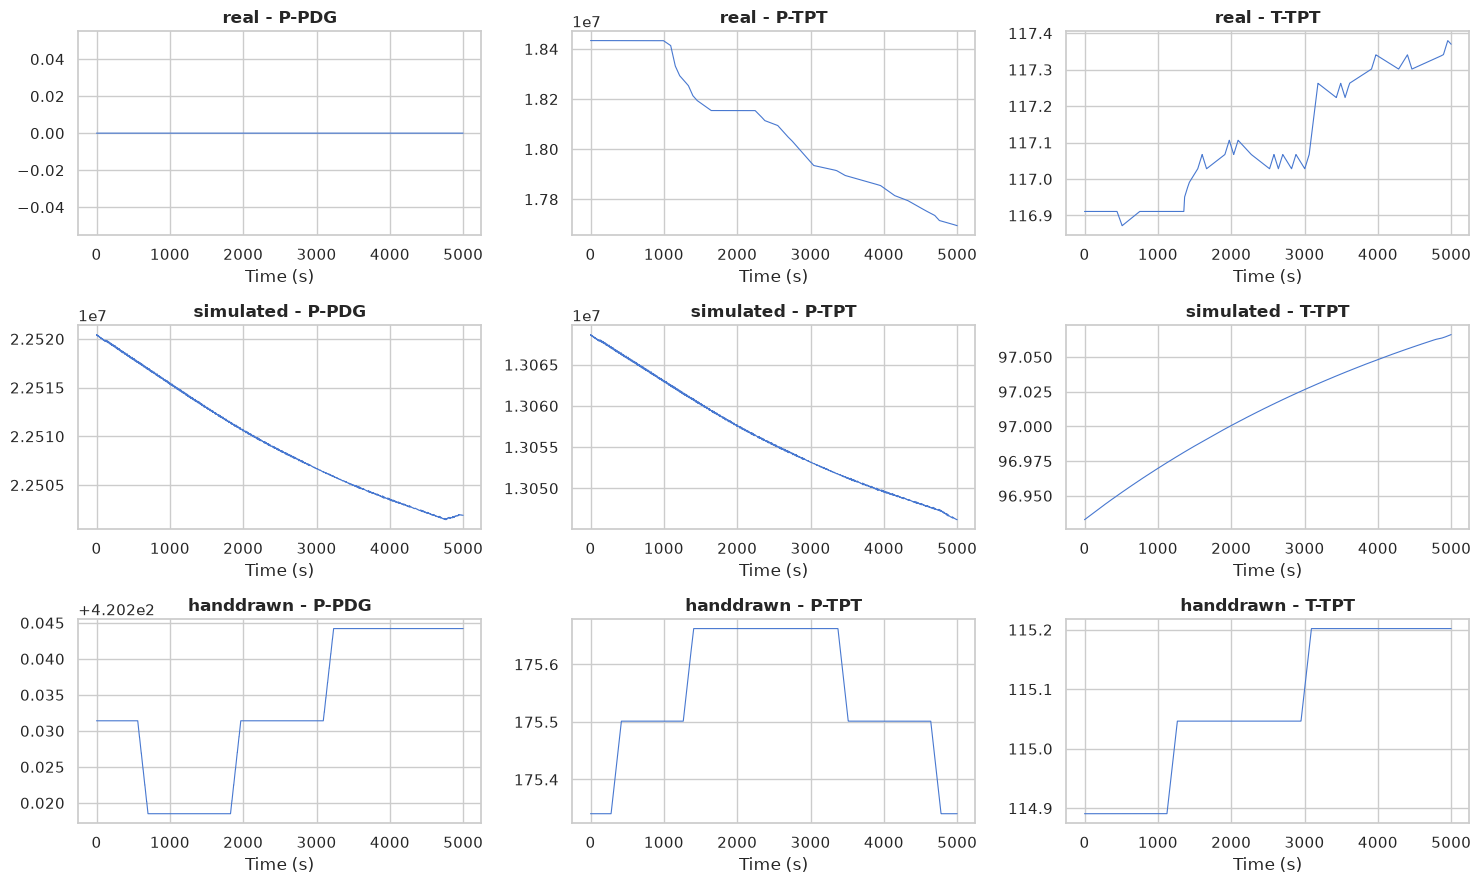

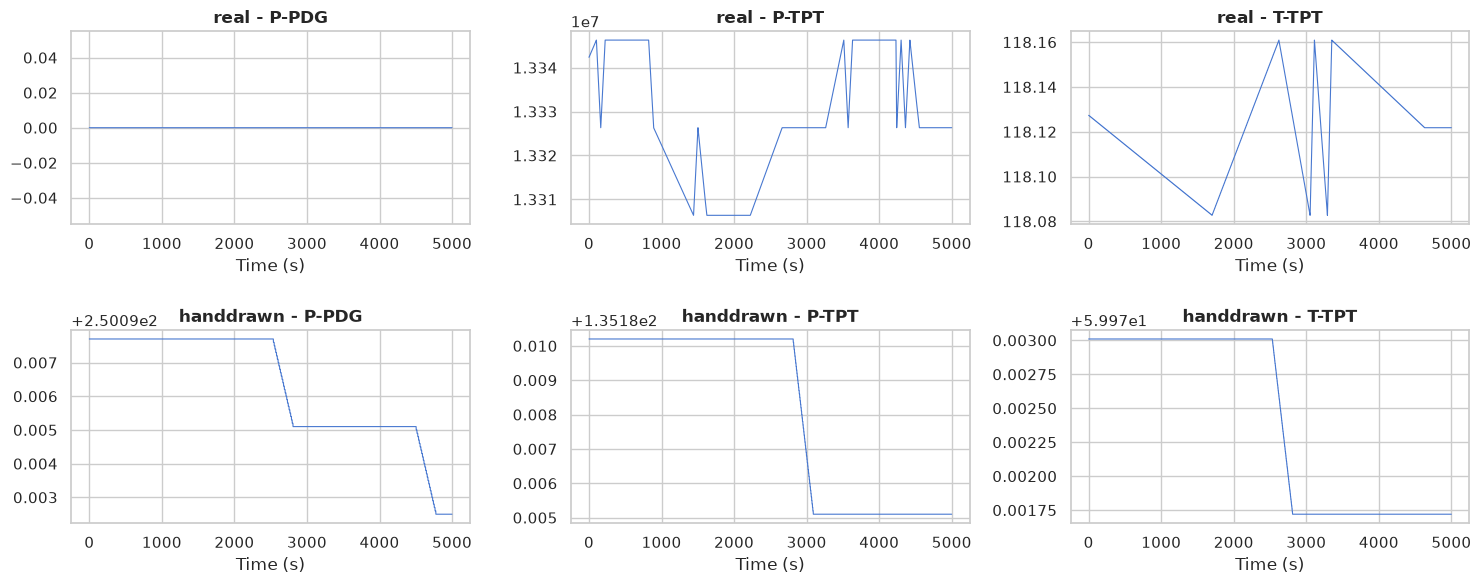

In [17]:
def compare_sources(data, class_code, class_name):
    """Plot same event from all available sources side by side.
    Args:
        data (dict): Loaded dataset
        class_code (int): Event class code
        class_name (str): Event class name
    """
    if class_code not in data:
        print(f'Class {class_code} not in data')
        return
    
    sources = ['real', 'simulated', 'handdrawn']
    available = [s for s in sources if s in data[class_code] and len(data[class_code][s]) > 0]
    
    if not available:
        print(f'No instances available for class {class_code}')
        return
    
    n_vars_to_plot = min(3, len(VARIABLE_NAMES))
    fig, axes = plt.subplots(len(available), n_vars_to_plot,
                             figsize=(5 * n_vars_to_plot, 3 * len(available)))
    
    if len(available) == 1:
        axes = [axes]
    
    for row, src in enumerate(available):
        inst = data[class_code][src][0]
        df = inst['data']
        cols_to_plot = [c for c in VARIABLE_NAMES[:n_vars_to_plot] if c in df.columns]
        for col_idx, var in enumerate(cols_to_plot):
            ax = axes[row][col_idx] if len(available) > 1 else axes[0][col_idx]
            vals = df[var].values[:5000]
            ax.plot(vals, linewidth=0.8)
            ax.set_title(f'{src} - {var}', fontweight='bold')
            ax.set_xlabel('Time (s)')
    
    plt.tight_layout()
    plt.show()


if 1 in data:
    compare_sources(data, 1, CLASS_NAMES[1])
if 7 in data:
    compare_sources(data, 7, CLASS_NAMES[7])

### Statistical comparison

We will run a KS test between the sources for each variable of class 1, to quantify how similar the distributions are.

In [18]:
if 1 in data:
    print('Distribution comparison: Class 1 (Abrupt Increase of BSW)\n')
    
    sources_available = [s for s in ['real', 'simulated', 'handdrawn']
                        if s in data[1] and len(data[1][s]) > 0]
    print(f'Sources available: {sources_available}')
    
    results = []
    for var in VARIABLE_NAMES:
        var_data = {}
        for src in sources_available:
            vals = []
            for inst in data[1][src]:
                if var in inst['data'].columns:
                    vals.extend(inst['data'][var].dropna().values[:10000])
            if len(vals) > 100:
                var_data[src] = np.array(vals)
        
        if len(var_data) >= 2:
            srcs = list(var_data.keys())
            for i in range(len(srcs)):
                for j in range(i+1, len(srcs)):
                    ks_stat, p_val = stats.ks_2samp(var_data[srcs[i]], var_data[srcs[j]])
                    results.append({
                        'Variable': var,
                        'S1': srcs[i],
                        'S2': srcs[j],
                        'KS_stat': round(ks_stat, 4),
                        'p_value': f'{p_val:.2e}',
                        'Same distribution (p>0.05)': 'YES' if p_val > 0.05 else 'NO',
                    })
    
    if results:
        display(pd.DataFrame(results))

Distribution comparison: Class 1 (Abrupt Increase of BSW)

Sources available: ['real', 'simulated', 'handdrawn']


,Variable,S1,S2,KS_stat,p_value,Same distribution (p>0.05)
0,P-PDG,real,simulated,0.6348,0.00e+00,NO
1,P-PDG,real,handdrawn,0.6109,0.00e+00,NO
2,P-PDG,simulated,handdrawn,1.0000,0.00e+00,NO
3,P-TPT,real,simulated,0.8947,0.00e+00,NO
4,P-TPT,real,handdrawn,1.0000,0.00e+00,NO
5,P-TPT,simulated,handdrawn,1.0000,0.00e+00,NO
6,T-TPT,real,simulated,1.0000,0.00e+00,NO
7,T-TPT,real,handdrawn,0.7000,0.00e+00,NO
8,T-TPT,simulated,handdrawn,0.9000,0.00e+00,NO
9,P-MON-CKP,real,simulated,0.9474,0.00e+00,NO


## 9. Summary

| Dimension | 3W Dataset |
|---|---|
| **Domain** | Offshore oil & gas wells (naturally flowing) |
| **Task types** | Binary classification, multi-class classification, anomaly detection, early classification, online/offline |
| **Number of variables** | 8 (pressure, temperature, flow-related) |
| **Number of classes** | 9 (1 normal + 8 undesirable event types) |
| **Number of instances** | 1,984 (1,025 real + 939 simulated + 20 hand-drawn) |
| **Sampling rate** | 1 Hz (fixed) |
| **Instance length** | Variable (seconds to days) |
| **Label granularity** | Per-instance (class directory) + per-observation (period codes) |
| **Data quality issues** | NaN (31% missing vars), frozen vars (10%), unlabeled obs (0.01%), outliers, class imbalance |
| **Temporal structure** | Event-specific windows: 5 min (DHSV) to 72 hours (Scaling) |
| **Source diversity** | Real + simulated (OLGA multiphase flow simulator) + expert hand-drawn |
| **Class imbalance** | Severe: 597 normal vs 428 abnormal (real), minimum 3 real instances for rarest event |